In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from scipy import linalg as LA
import random
import numpy.matlib
import kwant
import tinyarray
import multiprocessing as mp
import os
from tqdm import tqdm
import helpers as hp
from pathlib import Path
from config import PathConfigs
import scipy.sparse.linalg as sla
import multiprocessing as mp
from functools import partial
from scipy.signal import find_peaks



#pauli matrices
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

In [2]:

dir = Path(PathConfigs.DATA/"spectra_fix"/"Tdis_nb")
#dir = Path(PathConfigs.DATA/"nomushift"/"vdis2_b_strdis")
os.makedirs(Path(dir,"Plots"), exist_ok=True)

params = np.load(Path(dir/"all_params.npz"))

t = float(params['t'])
mu_n = float(params['mu_n'])
mu_leads =float(params['mu_leads'])
Delta0 = float(params['Delta0'])
gamma = float(params['gamma'])
alpha = float(params['alpha'])
Ln = int(params['Ln']) # normal metal length
Lb = int(params['Lb']) #barrier length
Ls = int(params['Ls']) #super conductor length
barrier_l = float(params['barrier0'])
V0 = float(params['V0'])
points = 100#int(params['Upoints'])

totlen = Ln + Lb +Ls 
#V_z = 1.0 * V_c # To generate Fig 2a V_z should be varied. For the cyan line in Fig 2, for example, V_z = 1.203 * V_c  
# 0.4864

#V_c = np.sqrt(mu**2 + Delta**2)
V_z = 0.690625
Vz_str = str(V_z).replace('.','_')

mu = 2.470982
mu_str = str(mu).replace('.','_')
barrier_r = np.linspace(barrier_l, 70*barrier_l, points)  #Varying the right barrier U_R

num_engs = 101 
energies = np.linspace(-0.5, 0.5, num_engs)

Vdisx = params['Vdisx']  * V0


paramd = {name:params[name] for name in params.files}
del paramd['Vdisx']
del paramd['energies']
del paramd['barrier_arr']
del paramd['mu_var']




In [3]:
def detect_peaks(ys, xs, thresh):
    diff = 1
    pos = None
    z_idx = np.where(xs.real == 0)[0][0]
    for i in range(z_idx, len(xs)):
        if i == 0:
            continue
        else:
            diff = ys[i] - ys[i-1]
            if diff < -thresh:
                pos = i-1
                break
    return pos
        
                

In [4]:
def detect_peaks_scipy(ys, xs):
    z_idx = np.where(xs.real == 0)[0][0]
    pks = find_peaks(ys)[0]

    if len(pks)==0:
        return None
    
    #center the peak indexes around the zero index
    zpks= pks - z_idx
    idxs = np.where(zpks >= 0)[0]
    #get the index of the peak closest to zero energy
    min_peak = np.min(pks[idxs[0]])
    
    return min_peak
    
 

In [7]:
eta = 0.001
rng = 0.11
ws = np.linspace(-rng, rng, 71) + eta * 1j
p1 = 0.001
p2 = 0.009

ps = [0.06, 0.015, 0.03, 0.04, 0.15]
amps = [0*5,0*3,0*4,1*0.1, 8]

def test_func(ws, poles, amps):
    res = np.zeros_like(ws)
    for p, a in zip(poles, amps):
        res += a/(ws + p)  + a/(ws - p)
    return res

dos = -test_func(ws, ps, amps).imag

res = hp.detect_peaks(dos, ws)




print(res)

48


/home/pseudonym/miniconda3/envs/kwant_fresh/lib/python3.8/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


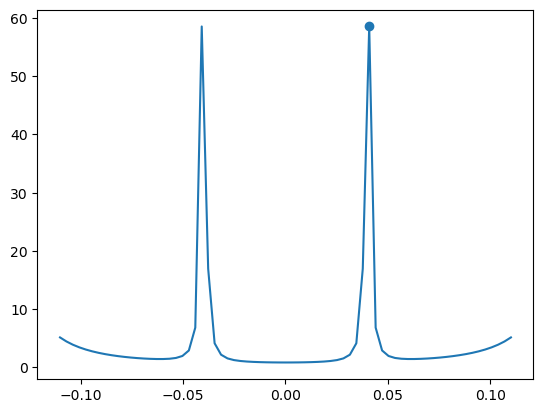

In [8]:


#pkbool, width = hp.detect_peaks(dos, ws, 0.1)
#pks,_ = find_peaks(dos)
#
#x = ws[pks]
#y = -test_func(x, ps, amps).imag

#print(f"min eig: {np.min(np.abs(x))}")

plt.plot(ws, dos)
if res is not None:
    plt.scatter(ws[res], dos[res])